In [1]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNetCV, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import statsmodels.api as sm

ID_COL = "PAT_ID"
T_COL = "T"
Y_COLS = ["Y1", "Y2", "Y3", "Y4", "Y5"]

TEST_SIZE = 0.2
RANDOM_STATE = 37

USE_PROPENSITY_WEIGHTING = True
MAX_INTERACTIONS_AUTO = 30

df = pd.read_excel("DataSet_A.xlsx")
df.columns = [c.strip() for c in df.columns]

if "x13" in df.columns and "X13" not in df.columns:
    df = df.rename(columns={"x13": "X13"})
if "chk_hour" in df.columns and "CHK_HOUR" not in df.columns:
    df = df.rename(columns={"chk_hour": "CHK_HOUR"})

dt_cols = df.select_dtypes(include=["datetime64[ns]", "datetime64"]).columns.tolist()
for c in dt_cols:
    s = df[c].view("int64").astype("float64")
    s[s < 0] = np.nan
    df[c] = s / 1e9

required = [T_COL] + Y_COLS
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df[T_COL] = pd.to_numeric(df[T_COL], errors="coerce")
df = df.dropna(subset=[T_COL] + Y_COLS).copy()
df[T_COL] = df[T_COL].astype(int)
df = df.dropna(subset=Y_COLS).reset_index(drop=True)

CAT_COLS = [
    "X16","X17","X19","X21","X22","X33","X34","X38","X39","X41",
    "X43","X44","X45","X46","X47","X48","X49","X50","X54","X55",
    "X56","X59","X60"
]

NUM_COLS = (
    [f"X{i}" for i in range(1,13)] +
    ["X13","X14","X15","X18","CHK_HOUR","X20"] +
    [f"X{i}" for i in range(23,33)] +
    [f"X{i}" for i in range(35,38)] +
    ["X40","X42","X51","X52","X53","X57","X58","X61","X62"]
)

exclude = set([T_COL] + Y_COLS + ([ID_COL] if ID_COL in df.columns else []))
X_all = [c for c in df.columns if c not in exclude]

cat_cols = [c for c in CAT_COLS if c in X_all]
num_cols = [c for c in NUM_COLS if c in X_all]

other_cols = [c for c in X_all if c not in cat_cols and c not in num_cols]
for c in other_cols:
    if pd.api.types.is_numeric_dtype(df[c]):
        num_cols.append(c)
    else:
        cat_cols.append(c)

num_cols = [c for c in num_cols if c in X_all]
cat_cols = [c for c in cat_cols if c in X_all]

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols),
    ],
    remainder="drop",
)

X_main = preprocess.fit_transform(df[X_all])

feat_names = []
feat_names.extend(num_cols)
if cat_cols:
    ohe = preprocess.named_transformers_["cat"].named_steps["onehot"]
    feat_names.extend(ohe.get_feature_names_out(cat_cols).tolist())

T = df[T_COL].to_numpy().reshape(-1, 1)

def select_interactions(y, X, names, k=30):
    model = ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.9, 1.0],
        alphas=np.logspace(-4, 2, 60),
        cv=5,
        random_state=RANDOM_STATE
    )
    model.fit(X, y)
    coef_abs = np.abs(model.coef_)
    order = np.argsort(coef_abs)[::-1]
    top = [names[i] for i in order if coef_abs[i] > 1e-12][:k]
    return top

y_anchor = df[Y_COLS[0]].to_numpy()
interaction_features = select_interactions(y_anchor, X_main, feat_names, k=MAX_INTERACTIONS_AUTO)

feat_map = {f: i for i, f in enumerate(feat_names)}
idx = [feat_map[f] for f in interaction_features if f in feat_map]

X_sel = X_main[:, idx]
TX = X_sel * T
X_full = np.hstack([T, X_main, TX])

def compute_iptw_weights(X, T):
    ps_model = LogisticRegression(max_iter=5000, solver="lbfgs")
    ps_model.fit(X, T.ravel())
    ps = ps_model.predict_proba(X)[:, 1]
    ps = np.clip(ps, 1e-3, 1 - 1e-3)
    p_t = T.mean()
    w = np.where(T.ravel() == 1, p_t / ps, (1 - p_t) / (1 - ps))
    return w

weights = compute_iptw_weights(X_main, T) if USE_PROPENSITY_WEIGHTING else np.ones(len(df))

def eval_regression(y_true, y_pred):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    r2 = float(r2_score(y_true, y_pred))
    return rmse, r2

def run_outcome(y, y_name):
    Xtr, Xte, ytr, yte = train_test_split(
        X_full, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )

    enet = ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.9, 1.0],
        alphas=np.logspace(-4, 2, 60),
        cv=5,
        random_state=RANDOM_STATE
    )
    enet.fit(Xtr, ytr)

    pred = enet.predict(Xte)
    rmse, r2 = eval_regression(yte, pred)

    print("\n" + "=" * 100)
    print(f"Outcome: {y_name}")
    print(f"ElasticNet: RMSE={rmse:.4f} | R^2={r2:.4f}")
    print(f"Interactions used: {len(idx)} (T×X)")

    inter_start = 1 + X_main.shape[1]
    inter_coefs = enet.coef_[inter_start:]
    top = np.argsort(np.abs(inter_coefs))[::-1][:12]

    print("\nTop effect modifiers (T×X) by |coef| from ElasticNet:")
    for i in top:
        if i < len(interaction_features):
            print(f"  T×{interaction_features[i]:50s}  coef={inter_coefs[i]:+.6f}")

    Xsm = sm.add_constant(X_full, has_constant="add")
    fit = sm.WLS(y, Xsm, weights=weights).fit(cov_type="HC3")

    t_coef = float(fit.params[1])
    t_pval = float(fit.pvalues[1])

    print(f"  coef(T) = {t_coef:+.6f} | p-value = {t_pval:.6g}")

    n = X_main.shape[0]
    ones = np.ones((n, 1))
    zeros = np.zeros((n, 1))

    X_full_t1 = np.hstack([ones, X_main, X_sel * ones])
    X_full_t0 = np.hstack([zeros, X_main, X_sel * zeros])

    y1_all = enet.predict(X_full_t1)
    y0_all = enet.predict(X_full_t0)
    te_all = y1_all - y0_all

    return te_all

print(f"Rows: {len(df):,}")
print(f"Raw X columns: {len(X_all)} | numeric: {len(num_cols)} | categorical: {len(cat_cols)}")
print(f"Expanded features after OHE: {len(feat_names):,}")
print(f"Datetime columns converted to numeric: {len(dt_cols)} -> {dt_cols}")

te_out = pd.DataFrame({ID_COL: df[ID_COL].values} if ID_COL in df.columns else {"row_id": np.arange(len(df))})

for ycol in Y_COLS:
    te = run_outcome(df[ycol].to_numpy(), ycol)
    te_out[f"TE_{ycol}"] = te

#te_out.to_csv("patient effects test results.csv", index=False), corrected below

te_out = te_out.rename(columns={
    "TE_Y1": "TE1",
    "TE_Y2": "TE2",
    "TE_Y3": "TE3",
    "TE_Y4": "TE4",
    "TE_Y5": "TE5",
})

#te_out.to_csv("Treatment Effects.csv", index=False)


print("\nSample of patient-specific treatment effects:")
print(te_out.head())



C:\Users\ty100\AppData\Local\Temp\ipykernel_28372\4023509812.py:34: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  s = df[c].view("int64").astype("float64")
C:\Users\ty100\AppData\Local\Temp\ipykernel_28372\4023509812.py:34: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  s = df[c].view("int64").astype("float64")


Rows: 100,000
Raw X columns: 63 | numeric: 40 | categorical: 23
Expanded features after OHE: 881
Datetime columns converted to numeric: 2 -> ['X14', 'X18']

Outcome: Y1
ElasticNet: RMSE=0.0578 | R^2=0.8636
Interactions used: 30 (T×X)

Top effect modifiers (T×X) by |coef| from ElasticNet:
  T×X5                                                  coef=+0.082965
  T×X4                                                  coef=+0.065287
  T×X3                                                  coef=+0.049927
  T×X2                                                  coef=+0.032590
  T×X1                                                  coef=+0.015781
  T×X36                                                 coef=-0.000757
  T×X27                                                 coef=+0.000709
  T×X30                                                 coef=+0.000252
  T×X37                                                 coef=-0.000163
  T×X10                                                 coef=+0.000095
 

C:\Users\ty100\anaconda3\envs\MSBA_class\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.911e+08, tolerance: 5.233e+08
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\ty100\anaconda3\envs\MSBA_class\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.141e+09, tolerance: 5.233e+08
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\ty100\anaconda3\envs\MSBA_class\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider i


Outcome: Y4
ElasticNet: RMSE=28.7801 | R^2=1.0000
Interactions used: 30 (T×X)

Top effect modifiers (T×X) by |coef| from ElasticNet:
  T×X8                                                  coef=+3332.580356
  T×X7                                                  coef=+2666.171093
  T×X6                                                  coef=+1999.604346
  T×X5                                                  coef=+1332.885152
  T×X4                                                  coef=+666.310834
  T×X56_card                                            coef=-4.330168
  T×X56_insurance                                       coef=-4.287743
  T×X10                                                 coef=+0.027015
  T×X36                                                 coef=+0.000000
  T×X42                                                 coef=-0.000000
  T×X25                                                 coef=+0.000000
  T×X61                                                 coef=-0.000000


In [39]:
import numpy as np
import pandas as pd

TE_A_PATH = "Treatment Effects.csv"
DATASET_B_PATH = "Dataset_B.xlsx"

OUT_SUBMISSION_PATH = "Team Osceola_2 DatasetB_Prediction.xlsx"
OUT_AUDIT_PATH = "DatasetB_Audit.xlsx"

WTP1, WTP2, WTP3 = 25000.0, 15000.0, 25000.0
PENALTY_SCALE = 25000.0

dfB = pd.read_excel(DATASET_B_PATH)
dfB.columns = dfB.columns.str.strip()

teA = pd.read_csv(TE_A_PATH)
teA.columns = teA.columns.str.strip()

TE_rep = teA[["TE1","TE2","TE3","TE4","TE5"]].mean()

V1 = float(TE_rep["TE1"]) * WTP1
V2 = -float(TE_rep["TE2"]) * WTP2
V3 = float(TE_rep["TE3"]) * WTP3

q01 = teA[["TE4","TE5"]].quantile(0.01)
q99 = teA[["TE4","TE5"]].quantile(0.99)

def scale01(x, lo, hi):
    if hi == lo:
        return 0.5
    return float(np.clip((x - lo) / (hi - lo), 0, 1))

V4 = -scale01(float(TE_rep["TE4"]), float(q01["TE4"]), float(q99["TE4"])) * PENALTY_SCALE
V5 = -float(TE_rep["TE5"]) * 1000.0

values = np.array([V1, V2, V3, V4, V5], dtype=float)

wp = dfB[["WP1","WP2","WP3","WP4","WP5"]].astype(float)
w = wp.div(wp.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.2)

scores = np.dot(w.values, values)
pred = np.where(scores > 0, "Surgery", "Conservative")

out = dfB[["PAT_ID"]].copy()
out["Predicted Treatment"] = pred
out.to_excel(OUT_SUBMISSION_PATH, index=False)

audit = dfB[["PAT_ID","WP1","WP2","WP3","WP4","WP5"]].copy()
audit["w1"] = w["WP1"]; audit["w2"] = w["WP2"]; audit["w3"] = w["WP3"]
audit["w4"] = w["WP4"]; audit["w5"] = w["WP5"]
audit["Score"] = scores
audit.to_excel(OUT_AUDIT_PATH, index=False)

print("(Dataset A mean, for TEs):")
print(TE_rep)
print("\nDollar-equivalents used for V1 to V5:")
print(values)


(Dataset A mean, for TEs):
TE1        0.250474
TE2       -0.199238
TE3        0.250286
TE4    19980.826807
TE5        5.994707
dtype: float64

Dollar-equivalents used for V1 to V5:
[  6261.8544794    2988.56670747   6257.15900899 -12474.48253219
  -5994.70737742]


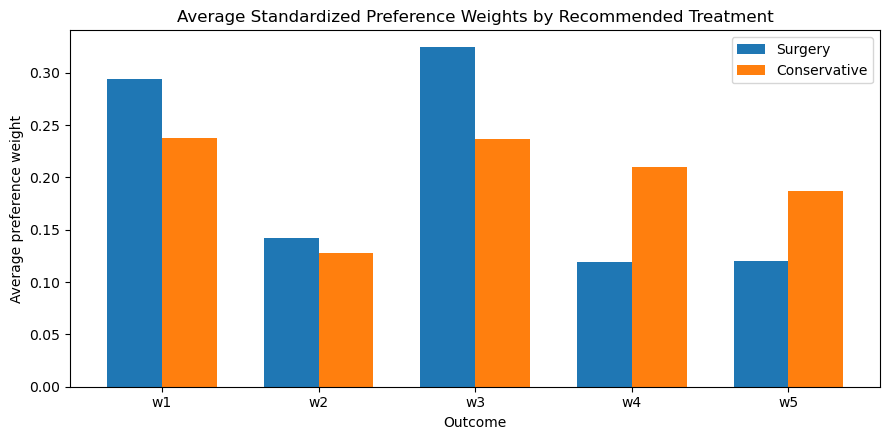

In [38]:
import matplotlib.pyplot as plt

AUDIT_PATH = "DatasetB_Audit.xlsx"
PRED_PATH = "Team Osceola_2 DatasetB_Prediction.xlsx"


df_audit = pd.read_excel(AUDIT_PATH)
df_pred  = pd.read_excel(PRED_PATH)


df = df_audit.merge(df_pred, on="PAT_ID", how="inner")


grp = (
    df
    .groupby("Predicted Treatment")[["w1","w2","w3","w4","w5"]]
    .mean()
    .reindex(["Surgery", "Conservative"])
)


labels = ["w1", "w2", "w3", "w4", "w5"]
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(9,4.5))
plt.bar(x - width/2, grp.loc["Surgery"], width, label="Surgery")
plt.bar(x + width/2, grp.loc["Conservative"], width, label="Conservative")

plt.title("Average Standardized Preference Weights by Recommended Treatment")
plt.ylabel("Average preference weight")
plt.xlabel("Outcome")
plt.xticks(x, labels)
plt.legend()
plt.tight_layout()

plt.savefig("avg_weights_by_group.png", dpi=200)
plt.show()


,PAT_ID,TE1,TE2,TE3,TE4,TE5
0,1,0.168021,-0.210573,0.332108,19335.234728,6.649916
1,2,0.364891,-0.344117,0.300652,24666.482152,5.831706
2,3,0.397205,-0.341130,0.300378,24666.493757,7.143269
3,4,0.199550,-0.106258,0.235725,16668.613319,6.149911
4,5,0.264162,-0.134184,0.102920,12673.669046,4.326844
...,...,...,...,...,...,...
99995,99996,0.432072,-0.241746,0.364792,25999.520212,6.093309
99996,99997,0.200918,-0.239206,0.398357,22001.071381,6.869918
99997,99998,0.233412,-0.133554,0.266971,18001.760782,6.369913
99998,99999,0.300994,-0.186244,0.333499,25999.574243,6.093309


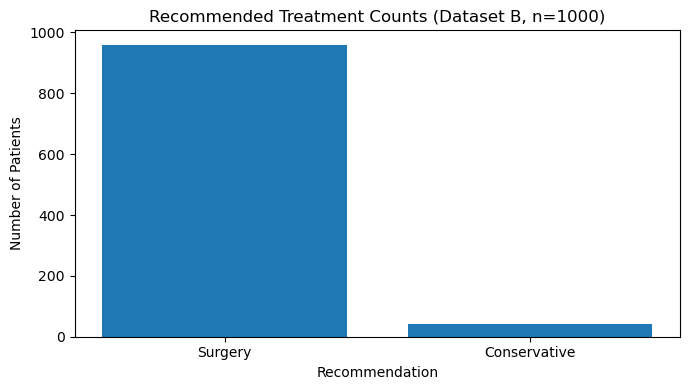

In [37]:
df_out = pd.read_excel("Team Osceola_2 DatasetB_Prediction.xlsx")


counts = (
    df_out["Predicted Treatment"]
    .value_counts()
    .reindex(["Surgery", "Conservative"])
    .fillna(0)
)


plt.figure(figsize=(7,4))
plt.bar(counts.index.astype(str), counts.values)
plt.title("Recommended Treatment Counts (Dataset B, n=1000)")
plt.ylabel("Number of Patients")
plt.xlabel("Recommendation")
plt.tight_layout()

plt.savefig("slide5_recommendations_bar.png", dpi=200)
plt.show()